# Dependencies

In [ ]:
import os
import glob
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

IMG_DIR   = 'input_images'
JSON_PATH = os.path.join('ground_truth_boxes', 'labelbox.json')
OUT_DIR   = 'iou_visual_output'
os.makedirs(OUT_DIR, exist_ok=True)

# ── Parameter ──────────────────────────────────────────────────
N             = 5       # jumlah frame untuk inisialisasi background
THRESHOLD     = 40      # threshold foreground detection
T1            = 30      # threshold update background (Statistical-Based)
BETA          = 0.1     # learning rate update background
MIN_AREA      = 300     # area minimum kontur agar dianggap objek
IOU_THRESHOLD = 0.5     # threshold IoU untuk TP/FP

# Fungsi utilitas

def calculate_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    return interArea / float(boxAArea + boxBArea - interArea + 1e-6)

def load_labelbox_json(json_path):
    gt_dict = {}
    if not os.path.exists(json_path):
        return gt_dict
    with open(json_path, 'r') as f:
        data = json.load(f)
    for item in data:
        filename = item.get("External ID", "")
        if not filename:
            continue
        labels = item.get("Label", {})
        boxes = []
        for class_name, objects in labels.items():
            if isinstance(objects, list):
                for obj in objects:
                    if "geometry" in obj:
                        geometry = obj["geometry"]
                        xs = [pt["x"] for pt in geometry]
                        ys = [pt["y"] for pt in geometry]
                        xmin, ymin = min(xs), min(ys)
                        xmax, ymax = max(xs), max(ys)
                        boxes.append([xmin, ymin, xmax, ymax])
        if filename:
            gt_dict[filename] = boxes
    return gt_dict

def draw_boxes_on_frame(frame_bgr, pred_boxes, gt_boxes, match_info):
    vis = frame_bgr.copy()
    matched_pred = {m[0] for m in match_info}
    matched_gt   = {m[1] for m in match_info}

    # Ground truth — hijau terang
    for i, box in enumerate(gt_boxes):
        x1, y1, x2, y2 = [int(v) for v in box]
        color = (0, 200, 80) if i in matched_gt else (0, 255, 200)
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis, "GT", (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)

    # Prediksi — oranye (TP) atau biru (FP)
    for i, box in enumerate(pred_boxes):
        x1, y1, x2, y2 = [int(v) for v in box]
        iou_val = 0.0
        for (pi, gi, iou) in match_info:
            if pi == i:
                iou_val = iou
                break
        if i in matched_pred:
            color = (0, 140, 255)   # TP = Oranye (BGR)
            label = f"TP {iou_val:.2f}"
        else:
            color = (221, 60, 0)    # FP = Biru (BGR)
            label = "FP"
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
        cv2.putText(vis, label, (x1, y2 + 14),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)
    return vis

def colorize_iou(iou_value):
    cmap = plt.cm.RdYlGn
    return cmap(iou_value)

# Muat data path dan ground truth
image_paths = glob.glob(os.path.join(IMG_DIR, '*.jpg'))
if len(image_paths) > 0:
    try:
        image_paths.sort(key=lambda x: int(os.path.splitext(os.path.basename(x))[0].split('_')[1]))
    except IndexError:
        image_paths.sort() # Fallback sorting jika format penamaan tidak pakai '_'

gt_data = load_labelbox_json(JSON_PATH)
print(f"Berhasil memuat {len(image_paths)} gambar dan {len(gt_data)} data Ground Truth.")

Berhasil memuat 98 gambar dan 98 data Ground Truth.


# Raw Image

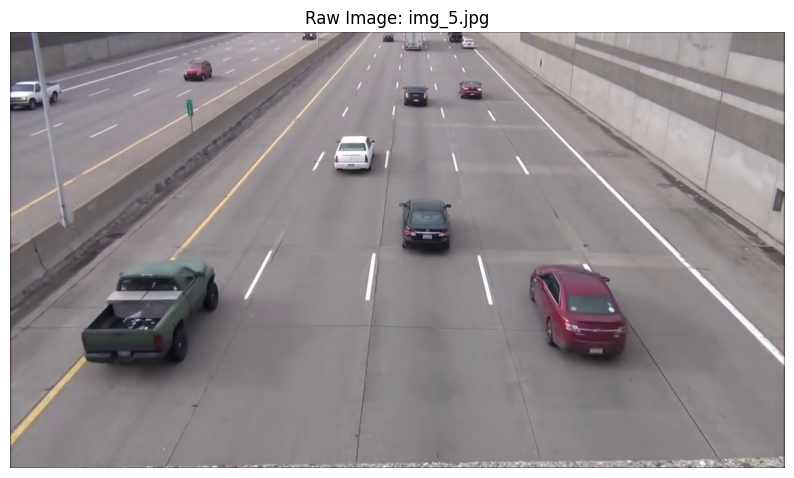

In [2]:
if len(image_paths) > 0:
    # Ambil frame ke-N (atau frame pertama jika gambar kurang dari N)
    sample_idx = min(N, len(image_paths) - 1)
    sample_path = image_paths[sample_idx]
    
    # Baca gambar dan konversi BGR ke RGB untuk Matplotlib
    raw_img_bgr = cv2.imread(sample_path)
    raw_img_rgb = cv2.cvtColor(raw_img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(raw_img_rgb)
    plt.title(f"Raw Image: {os.path.basename(sample_path)}")
    plt.axis("off")
    plt.show()
else:
    print("Folder input kosong, tidak ada gambar yang bisa ditampilkan.")

# Example background model

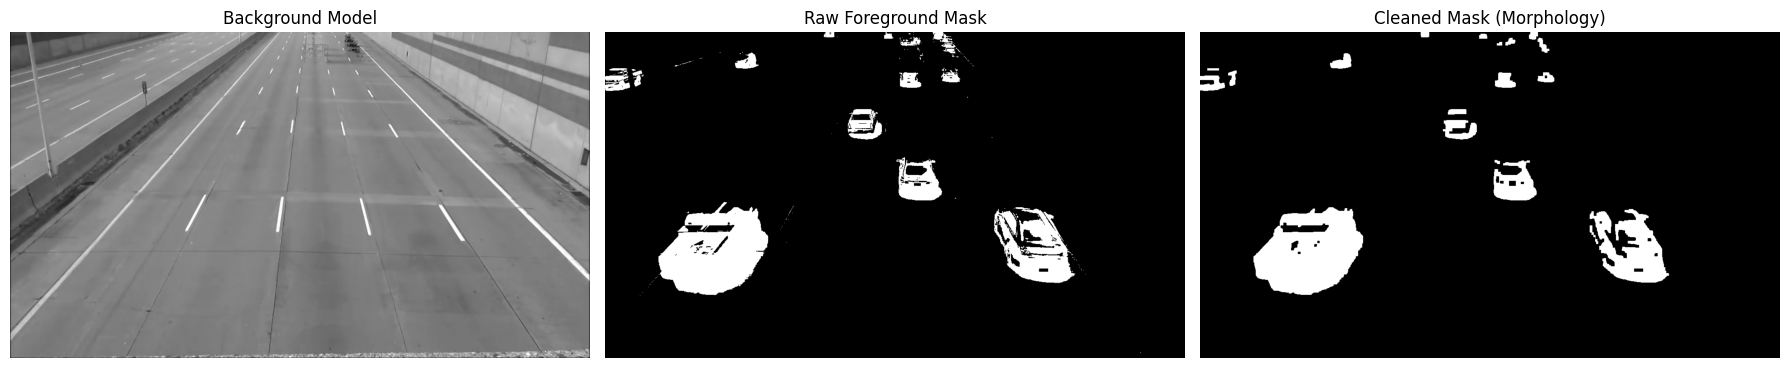

In [3]:
if len(image_paths) > N:
    # 1. Bangun model background awal untuk demonstrasi
    demo_buffer = []
    for i in range(N):
        img = cv2.imread(image_paths[i], cv2.IMREAD_GRAYSCALE).astype(np.float32)
        demo_buffer.append(img)
    demo_bg = np.median(np.stack(demo_buffer, axis=0), axis=0).astype(np.float32)

    # 2. Ambil satu frame untuk dites
    demo_frame_path = image_paths[N]
    demo_frame = cv2.imread(demo_frame_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)

    # 3. Background Subtraction
    diff_fg = np.abs(demo_frame - demo_bg)
    foreground_mask_raw = (diff_fg > THRESHOLD).astype(np.uint8) * 255

    # 4. Morphological Open & Close
    kernel = np.ones((5, 5), np.uint8)
    mask_open = cv2.morphologyEx(foreground_mask_raw, cv2.MORPH_OPEN, kernel)
    mask_cleaned = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)

    # Tampilkan perbandingan
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].imshow(demo_bg, cmap='gray')
    axes[0].set_title("Background Model")
    axes[0].axis("off")
    
    axes[1].imshow(foreground_mask_raw, cmap='gray')
    axes[1].set_title("Raw Foreground Mask")
    axes[1].axis("off")
    
    axes[2].imshow(mask_cleaned, cmap='gray')
    axes[2].set_title("Cleaned Mask (Morphology)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

# Modeling

In [ ]:
print(f"Membangun initial background model dari {N} frame pertama ...")
frames_buffer = []
for i in range(min(N, len(image_paths))):
    img = cv2.imread(image_paths[i], cv2.IMREAD_GRAYSCALE).astype(np.float32)
    frames_buffer.append(img)

if len(frames_buffer) > 0:
    background_model = np.median(np.stack(frames_buffer, axis=0), axis=0).astype(np.float32)

# Deteksi & Evaluasi
total_tp = 0; total_fp = 0; total_fn = 0
results = {
    "iou_per_frame": [], "tp_per_frame" : [],
    "fp_per_frame" : [], "fn_per_frame" : [],
    "vis_frames"   : [], "filenames"    : [],
}

print("Mulai proses deteksi ...")
for frame_i, img_path in enumerate(image_paths[N:]):
    frame     = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    frame_bgr = cv2.imread(img_path)
    filename  = os.path.basename(img_path)

    # a. Foreground Detection
    diff_fg = np.abs(frame - background_model)
    foreground_mask = (diff_fg > THRESHOLD).astype(np.uint8) * 255

    # b. Post-Processing
    kernel = np.ones((5, 5), np.uint8)
    foreground_mask = cv2.morphologyEx(foreground_mask, cv2.MORPH_OPEN,  kernel)
    foreground_mask = cv2.morphologyEx(foreground_mask, cv2.MORPH_CLOSE, kernel)

    # c. Statistical-Based Background Update
    frames_buffer.append(frame)
    if len(frames_buffer) > N:
        frames_buffer.pop(0)
    buffer_stack = np.stack(frames_buffer, axis=0)
    max_img      = np.max(buffer_stack, axis=0)
    min_img      = np.min(buffer_stack, axis=0)
    cond_mask    = (max_img - min_img) < T1
    mean_img     = (max_img + min_img) / 2.0
    background_model = np.where(
        cond_mask,
        (1 - BETA) * background_model + BETA * mean_img,
        background_model
    )

    # d. Ekstraksi Bounding Box
    contours, _ = cv2.findContours(foreground_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pred_boxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) > MIN_AREA:
            x, y, w, h = cv2.boundingRect(cnt)
            pred_boxes.append([x, y, x + w, y + h])

    # e. Evaluasi IoU
    gt_boxes   = gt_data.get(filename, [])
    matched_gt = set()
    match_info = []
    frame_tp = 0; frame_fp = 0

    for pi, pred_box in enumerate(pred_boxes):
        best_iou = 0; best_gt_idx = -1
        for gi, gt_box in enumerate(gt_boxes):
            iou = calculate_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou; best_gt_idx = gi
        if best_iou >= IOU_THRESHOLD and best_gt_idx not in matched_gt:
            total_tp += 1; frame_tp += 1
            matched_gt.add(best_gt_idx)
            match_info.append((pi, best_gt_idx, best_iou))
        else:
            total_fp += 1; frame_fp += 1

    frame_fn = len(gt_boxes) - len(matched_gt)
    total_fn += frame_fn

    # f. Visualisasi
    vis_frame = draw_boxes_on_frame(frame_bgr, pred_boxes, gt_boxes, match_info)
    frame_iou = np.mean([m[2] for m in match_info]) if match_info else 0.0
    iou_color = (0, int(255 * frame_iou), int(255 * (1 - frame_iou)))
    
    cv2.putText(vis_frame, f"IoU={frame_iou:.3f}  TP={frame_tp}  FP={frame_fp}  FN={frame_fn}",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(vis_frame, f"IoU={frame_iou:.3f}  TP={frame_tp}  FP={frame_fp}  FN={frame_fn}",
                (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, iou_color, 1, cv2.LINE_AA)

    results["iou_per_frame"].append(frame_iou)
    results["tp_per_frame"].append(frame_tp)
    results["fp_per_frame"].append(frame_fp)
    results["fn_per_frame"].append(frame_fn)
    results["vis_frames"].append(vis_frame)
    results["filenames"].append(filename)

    if (frame_i + 1) % 20 == 0:
        print(f"  Frame {frame_i + 1}/{len(image_paths[N:])} diproses ...")
        
print("Pemrosesan Selesai!")

Membangun initial background model dari 5 frame pertama ...
Mulai proses deteksi ...
  Frame 20/93 diproses ...
  Frame 40/93 diproses ...
  Frame 60/93 diproses ...
  Frame 80/93 diproses ...
Pemrosesan Selesai!


# Evaluasi

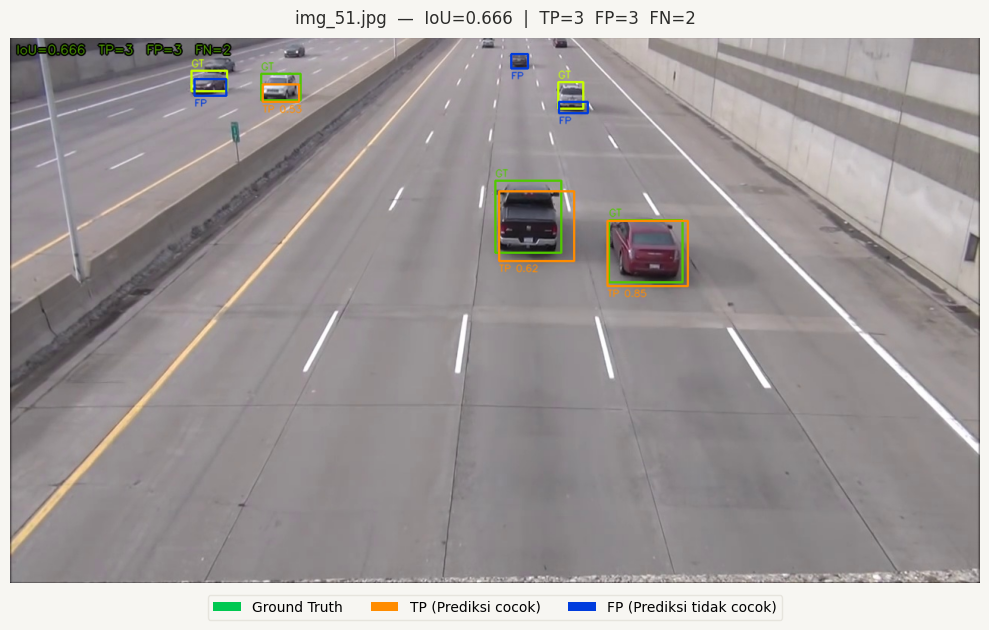


Selesai! Single frame tersimpan di -> iou_visual_output\single_frame_iou.png


In [5]:
if len(results["vis_frames"]) > 0:
    C_BG   = "#F7F6F2"
    C_TEXT = "#2C2C2A"
    C_GRID = "#E2E0D8"

    # Pilih frame di tengah sequence sebagai frame representatif
    idx = len(results["vis_frames"]) // 2

    vis_rgb = cv2.cvtColor(results["vis_frames"][idx], cv2.COLOR_BGR2RGB)
    iou_v   = results["iou_per_frame"][idx]
    tp      = results["tp_per_frame"][idx]
    fp      = results["fp_per_frame"][idx]
    fn      = results["fn_per_frame"][idx]
    fname   = results["filenames"][idx]

    fig, ax = plt.subplots(figsize=(10, 7), facecolor=C_BG)
    ax.imshow(vis_rgb)

    # Border warna sesuai rata-rata IoU frame tersebut
    edge_c = colorize_iou(iou_v)
    for sp in ax.spines.values():
        sp.set_edgecolor(edge_c); sp.set_linewidth(4)

    ax.set_title(
        f"{fname}  —  IoU={iou_v:.3f}  |  TP={tp}  FP={fp}  FN={fn}",
        fontsize=12, color=C_TEXT, pad=10
    )
    ax.axis("off")

    # Legenda yang sudah sinkron warnanya dengan Matplotlib RGB
    legend_elems = [
        mpatches.Patch(facecolor="#00C850", label="Ground Truth"),
        mpatches.Patch(facecolor="#FF8C00", label="TP (Prediksi cocok)"),
        mpatches.Patch(facecolor="#003CDD", label="FP (Prediksi tidak cocok)"),
    ]
    ax.legend(handles=legend_elems, loc="lower center",
              ncol=3, fontsize=10, facecolor=C_BG, edgecolor=C_GRID,
              bbox_to_anchor=(0.5, -0.08))

    fig.tight_layout()
    plt.show()

    # Menyimpan file sesuai alur kode aslinya
    out_path = os.path.join(OUT_DIR, "single_frame_iou.png")
    fig.savefig(out_path, dpi=130, bbox_inches="tight", facecolor=C_BG)
    print(f"\nSelesai! Single frame tersimpan di -> {out_path}")
else:
    print("Tidak ada frame hasil yang dapat ditampilkan.")